In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/")

from analysis.load_run_data import load_run_data
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
import pickle
from tqdm import tqdm
from sklearn.linear_model import LinearRegression, Lasso, MultiTaskLasso, LassoCV, MultiTaskLassoCV

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut

from sklearn.metrics import r2_score

from analysis.utils import extract_variables
import pickle


In [3]:
data = load_run_data('logs/initial_conditions', add_frames=True, n_frames=1)

Found 9 episode directories in logs/initial_conditions
Loaded 9 episodes
Loaded 9 planning episodes


In [ ]:
varsname_dict = {
    0: 'cart position',
    1: 'cos(pole angle)',
    2: 'sin(pole angle)',
    3: 'cart velocity',
    4: 'pole angular velocity',
}

varsname_dict_ext = {
    0: 'cart position',
    1: 'cos(pole angle)',
    2: 'sin(pole angle)',
    3: 'cart velocity',
    4: 'pole angular velocity',
    5: 'rewards',
    6: 'actions',
}

In [5]:
exp_vars = extract_variables(
    data,
    variables=['latent_states', 'observations', 'actions', 'rewards'],
    n_steps=500)

In [6]:
for var in exp_vars:
    print(f"{var}: {exp_vars[var][0].shape}")

latent_states: (500, 512)
observations: (500, 5)
actions: (500, 1)
rewards: (500, 1)


In [7]:
latents, observations, actions, rewards = (exp_vars['latent_states'],
                                           exp_vars['observations'],
                                           exp_vars['actions'],
                                           exp_vars['rewards'])

# Lasso decoding 


In [8]:
def compute_alphas(lassocv):
    mse_mean = lassocv.mse_path_.mean(axis=1)
    mse_se = lassocv.mse_path_.std(axis=1) / np.sqrt(lassocv.mse_path_.shape[1])
    idx_min = np.argmin(mse_mean)
    alpha_min = lassocv.alphas_[idx_min]
    candidates = lassocv.alphas_[mse_mean <= mse_mean[idx_min] +
                                 mse_se[idx_min]]
    alpha_1se = candidates.max()
    assert alpha_min == lassocv.alpha_
    return alpha_min, alpha_1se

In [9]:
# === FILL THIS WITH YOUR DATA ===
X_list = latents.copy()
y_action_list = actions.copy()
y_reward_list = rewards.copy()
y_obs_list = observations.copy()  # (Ti, 5)

X = np.concatenate(X_list, axis=0)
y_action = np.concatenate(y_action_list, axis=0)
y_reward = np.concatenate(y_reward_list, axis=0)
Y_obs = np.concatenate(y_obs_list, axis=0)

y_obs_cart_pos = Y_obs[:, 0][..., np.newaxis]
y_obs_cospole_ang = Y_obs[:, 1][..., np.newaxis]
y_obs_sinpole_ang = Y_obs[:, 2][..., np.newaxis]
y_obs_cart_vel = Y_obs[:, 3][..., np.newaxis]
y_obs_pole_vel = Y_obs[:, 4][..., np.newaxis]

groups = np.concatenate(
    [np.full(X_list[i].shape[0], i) for i in range(len(X_list))])
D = X.shape[1]

print(X.shape, y_action.shape, y_reward.shape, Y_obs.shape,
      y_obs_cart_pos.shape, y_obs_cospole_ang.shape, y_obs_sinpole_ang.shape,
      y_obs_cart_vel.shape, y_obs_pole_vel.shape)

(4500, 512) (4500, 1) (4500, 1) (4500, 5) (4500, 1) (4500, 1) (4500, 1) (4500, 1) (4500, 1)


In [ ]:
results = {}
targets = {
    "y_obs_cart_pos": y_obs_cart_pos,
    "y_obs_cospole_ang": y_obs_cospole_ang,
    "y_obs_sinpole_ang": y_obs_sinpole_ang,
    "y_obs_cart_vel": y_obs_cart_vel,
    "y_obs_pole_vel": y_obs_pole_vel,
    "action": y_action,
    "reward": y_reward,
    'obs_all': Y_obs,
    "all": np.concatenate([Y_obs, y_reward, y_action], axis=1)
}

n_alphas = 60
max_iter = 5000

for name, y in targets.items():

    # Leave-one-episode-out CV in LassoCV
    logo = LeaveOneGroupOut()

    print(f"=== Fitting LASSO for {name} ===")
    if y.shape[1] == 1:
        cv_splits = list(logo.split(X, y, groups=groups))
        lassocv = LassoCV(cv=cv_splits, n_alphas=n_alphas,
                          max_iter=max_iter).fit(X, y)
        alpha_min, alpha_1se = compute_alphas(lassocv)
        lasso_1se = Lasso(alpha=alpha_1se, max_iter=max_iter).fit(X, y)
        r2_min = lassocv.score(X, y)
        r2_1se = lasso_1se.score(X, y)

    elif y.shape[1] > 1:
        cv_splits = list(logo.split(X, None, groups=groups))
        lassocv = MultiTaskLassoCV(cv=cv_splits,
                                   n_alphas=n_alphas,
                                   max_iter=max_iter).fit(X, y)
        alpha_min = lassocv.alpha_
        alpha_1se = alpha_min * 2.0  # recommended conservative choice
        lasso_1se = MultiTaskLasso(alpha=alpha_1se, max_iter=max_iter).fit(X, y)
        r2_min = lassocv.score(X, y)
        r2_1se = lasso_1se.score(X, y)

    results[name] = {
        "lasso": lassocv,
        "lasso_1se": lasso_1se,
        "coef_min": lassocv.coef_,
        "coef_1se": lasso_1se.coef_,
        "alpha_min": alpha_min,
        "alpha_1se": alpha_1se,
        "r2_min": r2_min,
        "r2_1se": r2_1se,
    }

# with open('lasso_results_initial_conditions.pkl', 'wb') as f:
#     pickle.dump(
#         {
#             'results': results,
#             'targets': targets,
#             'X': X,
#             'groups': groups
#         }, f)

# print("Results saved to lasso_results.pkl")

=== Fitting LASSO for y_obs_cart_pos ===


/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:1664: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


=== Fitting LASSO for y_obs_cospole_ang ===


/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:1664: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


=== Fitting LASSO for y_obs_sinpole_ang ===


...

=== Fitting LASSO for action ===


/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:1664: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.08107833564281464, tolerance: 0.04966404661536217
  model = cd_fast.enet_coordinate_descent_gram(
/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.1548101305961609, tolerance: 0.04966404661536217
  model = cd_fast.enet_coordinate_descent_gram(
/h

=== Fitting LASSO for reward ===


/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:1664: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


=== Fitting LASSO for obs_all ===
=== Fitting LASSO for all ===
Results saved to lasso_results.pkl


In [ ]:
B = 200
rng = np.random.RandomState(0)

# Store bootstrap coefficients for both alpha_min and alpha_1se
bootstrap_coefs = {name: {'min': [], '1se': []} for name in targets.keys()}

for b in tqdm(range(B)):
    eps = rng.choice(len(X_list), len(X_list), replace=True)

    # bootstrap X
    Xb = np.concatenate([X_list[i] for i in eps])

    # bootstrap y for each target
    for tname, y in targets.items():
        is_single = (y.shape[1] == 1)

        # ---- build bootstrapped target ----
        if is_single:
            yb = np.concatenate([targets[tname][groups == i] for i in eps])
        else:
            yb = np.concatenate([targets[tname][groups == i, :] for i in eps],
                                axis=0)

        alpha_min = results[tname]["alpha_min"]
        alpha_1se = results[tname]["alpha_1se"]

        if is_single:
            model_min = Lasso(alpha=alpha_min, max_iter=max_iter).fit(Xb, yb)
            model_1se = Lasso(alpha=alpha_1se, max_iter=max_iter).fit(Xb, yb)
            bootstrap_coefs[tname]['min'].append(model_min.coef_)
            bootstrap_coefs[tname]['1se'].append(model_1se.coef_)

        else:
            model_min = MultiTaskLasso(alpha=alpha_min,
                                       max_iter=max_iter).fit(Xb, yb)
            model_1se = MultiTaskLasso(alpha=alpha_1se,
                                       max_iter=max_iter).fit(Xb, yb)
            bootstrap_coefs[tname]['min'].append(model_min.coef_)
            bootstrap_coefs[tname]['1se'].append(model_1se.coef_)

# # Save bootstrap coefficients to pickle file
# with open('bootstrap_coefs.pkl', 'wb') as f:
#     pickle.dump(bootstrap_coefs, f)

#print("Bootstrap coefficients saved to bootstrap_coefs.pkl")

# # Convert lists to arrays
# for tname in bootstrap_coefs:
#     bootstrap_coefs[tname]['min'] = np.array(bootstrap_coefs[tname]['min'])
#     bootstrap_coefs[tname]['1se'] = np.array(bootstrap_coefs[tname]['1se'])

  0%|          | 0/200 [00:00<?, ?it/s]/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.588e-01, tolerance: 1.942e-01
  model = cd_fast.enet_coordinate_descent(
  0%|          | 1/200 [00:34<1:55:50, 34.93s/it]

  1%|          | 2/200 [01:18<2:11:26, 39.83s/it]/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.579e-01, tolerance: 1.879e-01
  model = cd_fast.enet_coordinate_descent(
/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.204e-01, tolerance: 5.444e-02
  model = cd_fast.enet_coordinate_descent(
  2%|▎         | 5/200 [03:14<2:02:49, 37.79s/it]/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: C

Bootstrap coefficients saved to bootstrap_coefs.pkl


## Analysis of lasso models

In [10]:
# Load the saved results
with open(
        '/home/hgf_hmgu/hgf_gib4562/tdmpc2/lasso_results_initial_conditions.pkl',
        'rb') as f:
    lasso_results = pickle.load(f)

# Load the bootstrap coefficients
with open('/home/hgf_hmgu/hgf_gib4562/tdmpc2/bootstrap_coefs.pkl', 'rb') as f:
    bootstrap_coefs = pickle.load(f)

# Convert bootstrap coefficient lists to arrays for easier analysis
for tname in bootstrap_coefs:
    bootstrap_coefs[tname]['min'] = np.array(bootstrap_coefs[tname]['min'])
    bootstrap_coefs[tname]['1se'] = np.array(bootstrap_coefs[tname]['1se'])

print("Loaded lasso results and bootstrap coefficients")
print(f"Target variables: {list(lasso_results.keys())}")
print(
    f"Number of bootstrap samples: {bootstrap_coefs[list(bootstrap_coefs.keys())[0]]['min'].shape[0]}"
)


Loaded lasso results and bootstrap coefficients
Target variables: ['results', 'targets', 'X', 'groups']
Number of bootstrap samples: 200


In [46]:
lasso_results['results'].keys()

dict_keys(['y_obs_cart_pos', 'y_obs_cospole_ang', 'y_obs_sinpole_ang', 'y_obs_cart_vel', 'y_obs_pole_vel', 'action', 'reward', 'obs_all', 'all'])

In [303]:
# Convert raw coefficients to selection matrices

stability = {name: {} for name in bootstrap_coefs.keys()}

thr = 0.1
for name in bootstrap_coefs:
    # stack over bootstrap iterations
    coefs_min = np.array(bootstrap_coefs[name]['min'])
    coefs_1se = np.array(bootstrap_coefs[name]['1se'])

    # Handle multi-task: convert shape (B, n_targets, D) → (B, D)
    if coefs_min.ndim == 3:
        sel_min_all = (np.abs(coefs_min) > thr).astype(float)
        sel_1se_all = (np.abs(coefs_1se) > thr).astype(float)
        sel_min = (np.any(np.abs(coefs_min) > thr, axis=1)).astype(float)
        sel_1se = (np.any(np.abs(coefs_1se) > thr, axis=1)).astype(float)
        stability[name]['min_all'] = sel_min_all.mean(axis=0)
        stability[name]['1se_all'] = sel_1se_all.mean(axis=0)
    else:
        # single-task: (B, D)
        sel_min = (np.abs(coefs_min) > thr).astype(float)
        sel_1se = (np.abs(coefs_1se) > thr).astype(float)

    # selection probability
    stability[name]['min'] = sel_min.mean(axis=0)  # shape (D,)
    stability[name]['1se'] = sel_1se.mean(axis=0)  # shape (D,)

In [336]:
# Create dictionary to store selected latents at different thresholds
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
selected_latents = {name: {'1se': {}, 'min': {}} for name in stability}

for name in stability:
    p_1se = stability[name]['1se']
    p_min = stability[name]['min']

    # Store selected latents for each threshold
    for thr in thresholds:
        selected_latents[name]['1se'][thr] = np.where(p_1se >= thr)[0].tolist()
        selected_latents[name]['min'][thr] = np.where(p_min >= thr)[0].tolist()

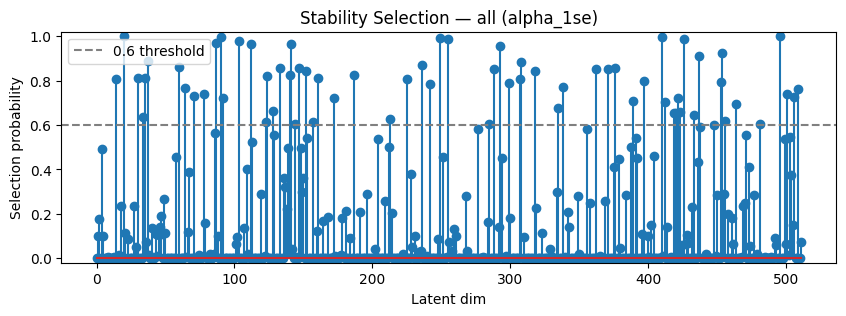

In [338]:
# Plot for 1se
plt.figure(figsize=(10, 3))
plt.stem(range(len(p_1se)), p_1se)
plt.axhline(0.6, color='gray', linestyle='--', label='0.6 threshold')
plt.ylim(-0.02, 1.02)
plt.title(f"Stability Selection — {name} (alpha_1se)")
plt.xlabel("Latent dim")
plt.ylabel("Selection probability")
plt.legend()
plt.show()

In [341]:
# Save selected latents to pickle
import pickle

# Save selected latents dictionary
output_file = 'selected_latents_lasso.pkl'
with open(output_file, 'wb') as f:
    pickle.dump(selected_latents, f)

print(f"Saved selected latents to: {output_file}")

Saved selected latents to: selected_latents_lasso.pkl


## compare variable-specific and multitask selection

## NOTE: Apparently all the variabels acrsoso the diffferent tasks have same non-zero coefficients although the coeffcieients are not the same. very weird...

In [304]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

vars_to_compare = [
    'y_obs_cart_pos',
    'y_obs_cospole_ang',
    'y_obs_sinpole_ang',
    'y_obs_cart_vel',
    'y_obs_pole_vel',
    'action',
    'reward',
]

threshold = 0.4

rows = []


def jaccard(a, b):
    A, B = set(a), set(b)
    if len(A) == 0 and len(B) == 0:
        return 1.0
    return len(A & B) / len(A | B)


for idx, name in enumerate(vars_to_compare):

    # ----- extract variable stability vectors -----
    v_1se = stability[name]['1se']  # shape (D,)
    v_min = stability[name]['min']  # shape (D,)

    # ----- extract multitask stability -----
    mts_1se = stability['all']['1se_all'][idx]  # shape (D,)
    mts_min = stability['all']['min_all'][idx]  # shape (D,)

    # ----- thresholded selections -----
    var_sel_1se = np.where(v_1se > threshold)[0]
    var_sel_min = np.where(v_min > threshold)[0]
    all_sel_1se = np.where(mts_1se > threshold)[0]
    all_sel_min = np.where(mts_min > threshold)[0]

    # ----- overlaps -----
    intersect_1se = sorted(list(set(var_sel_1se) & set(all_sel_1se)))
    intersect_min = sorted(list(set(var_sel_min) & set(all_sel_min)))

    # ----- save row -----
    rows.append({
        "variable": name,

        # counts
        "n_var_1se": len(var_sel_1se),
        "n_all_1se": len(all_sel_1se),
        "n_intersect_1se": len(intersect_1se),
        "n_var_min": len(var_sel_min),
        "n_all_min": len(all_sel_min),
        "n_intersect_min": len(intersect_min),

        # Jaccard
        "jaccard_1se": jaccard(var_sel_1se, all_sel_1se),
        "jaccard_min": jaccard(var_sel_min, all_sel_min),

        # directional overlaps
        "frac_var_in_all_1se": len(intersect_1se) / (len(var_sel_1se) + 1e-8),
        "frac_all_in_var_1se": len(intersect_1se) / (len(all_sel_1se) + 1e-8),
        "frac_var_in_all_min": len(intersect_min) / (len(var_sel_min) + 1e-8),
        "frac_all_in_var_min": len(intersect_min) / (len(all_sel_min) + 1e-8),

        # lists if you want to inspect them
        "var_sel_1se": var_sel_1se.tolist(),
        "all_sel_1se": all_sel_1se.tolist(),
        "intersect_1se": intersect_1se,
        "var_sel_min": var_sel_min.tolist(),
        "all_sel_min": all_sel_min.tolist(),
        "intersect_min": intersect_min,
    })

df_compare = pd.DataFrame(rows)
df_compare


,variable,n_var_1se,n_all_1se,n_intersect_1se,n_var_min,n_all_min,n_intersect_min,jaccard_1se,jaccard_min,frac_var_in_all_1se,frac_all_in_var_1se,frac_var_in_all_min,frac_all_in_var_min,var_sel_1se,all_sel_1se,intersect_1se,var_sel_min,all_sel_min,intersect_min
0,y_obs_cart_pos,18,31,10,22,31,14,0.256410,0.358974,0.555556,0.322581,0.636364,0.451613,"[20, 133, 147, 184, 234, 236, 261, 338, 356, 3...","[4, 20, 30, 35, 60, 71, 87, 103, 112, 133, 147...","[20, 133, 147, 236, 338, 362, 388, 391, 426, 464]","[4, 14, 20, 103, 133, 147, 158, 184, 187, 222,...","[4, 14, 20, 30, 35, 60, 71, 87, 103, 112, 133,...","[4, 14, 20, 103, 133, 147, 187, 236, 338, 362,..."
1,y_obs_cospole_ang,12,28,5,17,27,7,0.142857,0.189189,0.416667,0.178571,0.411765,0.259259,"[30, 38, 58, 97, 147, 307, 334, 349, 356, 400,...","[14, 30, 35, 60, 78, 103, 112, 133, 140, 144, ...","[30, 147, 307, 356, 496]","[30, 38, 45, 58, 97, 102, 147, 307, 315, 334, ...","[4, 30, 35, 58, 60, 103, 112, 133, 144, 147, 1...","[30, 58, 147, 307, 356, 397, 496]"
2,y_obs_sinpole_ang,19,24,11,26,26,11,0.343750,0.268293,0.578947,0.458333,0.423077,0.423077,"[18, 20, 60, 87, 128, 129, 133, 184, 187, 236,...","[20, 37, 60, 87, 90, 124, 128, 129, 133, 187, ...","[20, 60, 87, 128, 129, 133, 187, 236, 376, 397...","[18, 20, 44, 55, 60, 87, 88, 108, 110, 129, 13...","[20, 37, 60, 87, 90, 128, 129, 133, 187, 225, ...","[20, 60, 87, 129, 133, 187, 236, 376, 389, 397..."
3,y_obs_cart_vel,29,62,23,53,73,34,0.338235,0.369565,0.793103,0.370968,0.641509,0.465753,"[21, 36, 37, 60, 71, 78, 87, 90, 101, 123, 141...","[20, 30, 34, 35, 37, 58, 60, 64, 71, 78, 86, 8...","[37, 60, 71, 78, 87, 90, 123, 141, 147, 157, 2...","[20, 21, 27, 36, 37, 53, 60, 64, 71, 78, 82, 8...","[4, 20, 27, 30, 34, 35, 36, 37, 58, 60, 64, 71...","[20, 27, 36, 37, 60, 64, 71, 78, 87, 88, 90, 1..."
4,y_obs_pole_vel,25,81,23,55,92,49,0.277108,0.500000,0.920000,0.283951,0.890909,0.532609,"[14, 20, 78, 92, 103, 109, 112, 133, 140, 141,...","[4, 14, 20, 30, 34, 35, 37, 58, 60, 64, 71, 78...","[14, 20, 78, 92, 103, 112, 133, 140, 141, 212,...","[4, 14, 20, 34, 35, 60, 67, 71, 87, 92, 103, 1...","[4, 14, 20, 30, 34, 35, 37, 58, 60, 64, 67, 71...","[4, 14, 20, 34, 35, 60, 67, 71, 87, 92, 103, 1..."
5,action,18,20,5,38,18,6,0.151515,0.120000,0.277778,0.250000,0.157895,0.333333,"[37, 40, 46, 86, 124, 128, 129, 136, 152, 228,...","[35, 37, 64, 124, 133, 161, 249, 255, 299, 307...","[37, 124, 335, 371, 410]","[30, 37, 38, 40, 71, 86, 92, 109, 112, 124, 12...","[35, 37, 64, 124, 133, 225, 255, 299, 307, 335...","[37, 124, 307, 371, 410, 506]"
6,reward,9,59,6,10,78,5,0.096774,0.060241,0.666667,0.101695,0.500000,0.064103,"[35, 299, 307, 335, 349, 375, 395, 464, 496]","[14, 20, 30, 34, 35, 37, 60, 71, 78, 86, 87, 9...","[35, 299, 307, 335, 375, 496]","[35, 299, 307, 335, 349, 362, 375, 395, 464, 496]","[14, 20, 27, 30, 34, 35, 37, 40, 60, 71, 78, 7...","[35, 299, 307, 375, 496]"


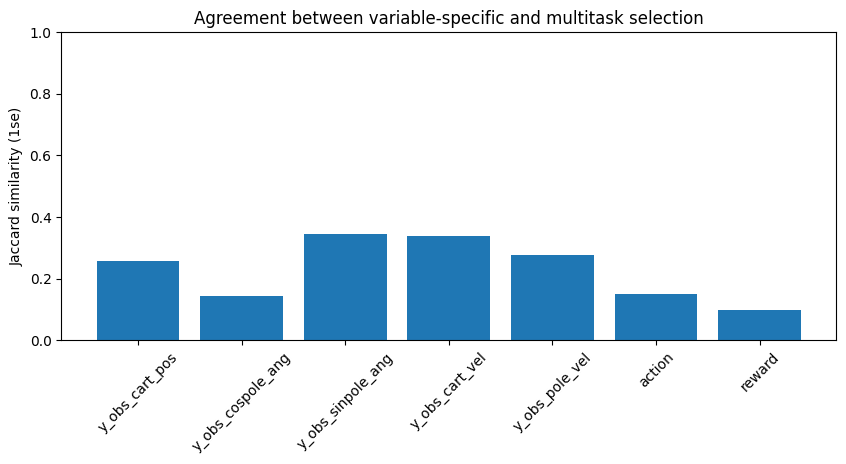

In [305]:
plt.figure(figsize=(10, 4))
plt.bar(df_compare["variable"], df_compare["jaccard_1se"])
plt.xticks(rotation=45)
plt.ylabel("Jaccard similarity (1se)")
plt.title("Agreement between variable-specific and multitask selection")
plt.ylim(0, 1)
plt.show()

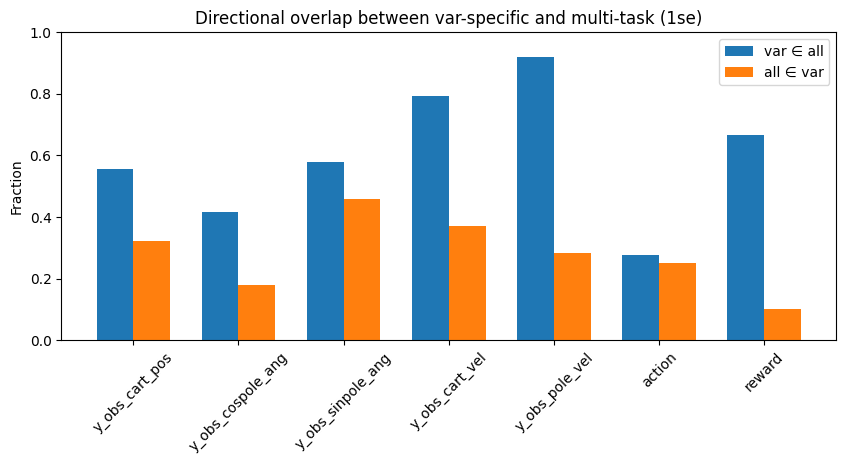

In [306]:
x = np.arange(len(df_compare))
width = 0.35

plt.figure(figsize=(10, 4))
plt.bar(x - width / 2,
        df_compare["frac_var_in_all_1se"],
        width,
        label="var ∈ all")
plt.bar(x + width / 2,
        df_compare["frac_all_in_var_1se"],
        width,
        label="all ∈ var")
plt.xticks(x, df_compare["variable"], rotation=45)
plt.ylim(0, 1)
plt.ylabel("Fraction")
plt.title("Directional overlap between var-specific and multi-task (1se)")
plt.legend()
plt.show()
